In [ ]:
# Notebook 05: SHAP Explainability Analysis

In [ ]:
## Introduction

Predictive performance alone is often insufficient in healthcare applications, where understanding the reasoning behind model predictions is essential.
Explainable Artificial Intelligence (XAI) techniques improve transparency and help clinicians interpret model decisions.

This notebook applies SHAP (SHapley Additive exPlanations) to the best-performing Random Forest classifier developed in Notebook 03.
SHAP values quantify the contribution of each feature to the model's predictions, allowing both global and local interpretation.

In [ ]:
## Objectives

- Load the trained Random Forest model.
- Load the preprocessed dataset.
- Compute SHAP values.
- Generate global feature importance.
- Visualise feature effects.
- Interpret the contribution of clinical variables to heart disease prediction.

In [1]:
from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data"
PROCESSED_PATH = DATA_PATH / "processed"

MODEL_PATH = PROJECT_ROOT / "models"
FIGURES_PATH = PROJECT_ROOT / "Figures"

FIGURES_PATH.mkdir(exist_ok=True)

In [3]:
train_df = pd.read_csv(
    PROCESSED_PATH / "heart_train_processed.csv"
)

test_df = pd.read_csv(
    PROCESSED_PATH / "heart_test_processed.csv"
)

train_df.shape, test_df.shape

((242, 14), (61, 14))

In [4]:
X_train = train_df.drop("target", axis=1)
y_train = train_df["target"]

X_test = test_df.drop("target", axis=1)
y_test = test_df["target"]

X_train.shape

(242, 13)

In [5]:
rf_model = joblib.load(MODEL_PATH / "random_forest.pkl")

print("Random Forest model loaded successfully.")

Random Forest model loaded successfully.


In [10]:
explainer = shap.Explainer(rf_model)

shap_values = explainer(X_test)

print(type(shap_values))
print(shap_values.shape)

<class 'shap._explanation.Explanation'>
(61, 13, 2)


In [ ]:
## Global Feature Importance

This plot ranks the clinical variables according to their overall contribution to the Random Forest model.
Features with larger SHAP values have a greater influence on predicting heart disease.

In [9]:
import shap

print(shap.__version__)

0.51.0


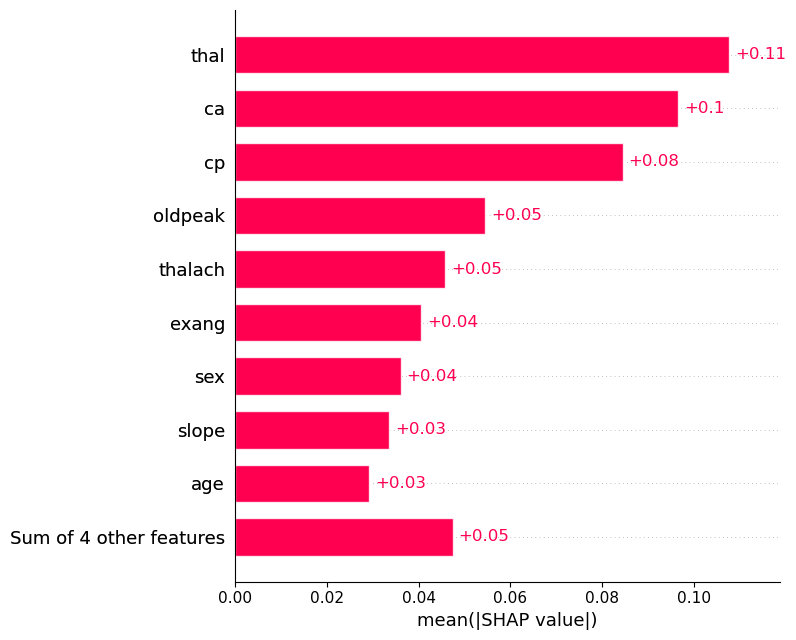

In [12]:
plt.figure(figsize=(10, 6))

shap.plots.bar(shap_values[:, :, 1], show=False)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
## SHAP Summary Plot

The SHAP summary (beeswarm) plot illustrates both the importance of each feature and the direction of its influence on the model's predictions.
Each point represents an individual patient, with colour indicating the feature value and horizontal position representing the SHAP value.

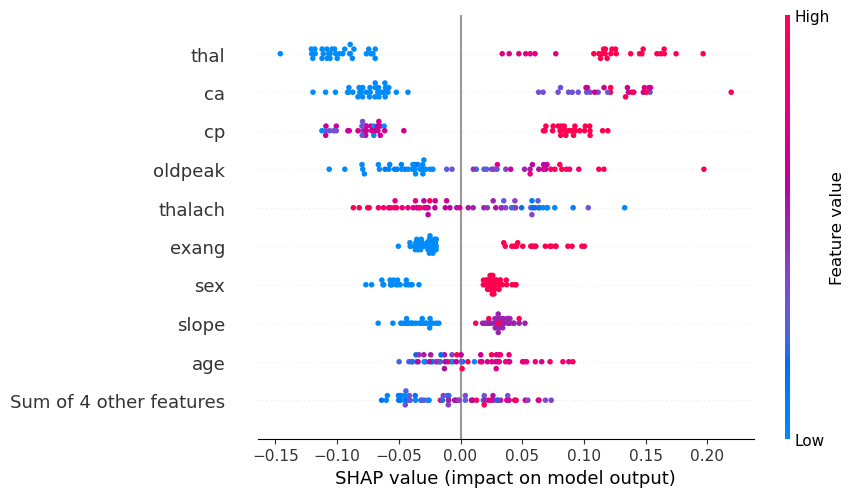

In [13]:
plt.figure(figsize=(10, 7))

shap.plots.beeswarm(
    shap_values[:, :, 1],
    show=False
)

plt.savefig(
    FIGURES_PATH / "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
## Local Explanation

The waterfall plot explains the prediction for a single patient by showing how each feature contributes positively or negatively
towards the predicted probability of heart disease.

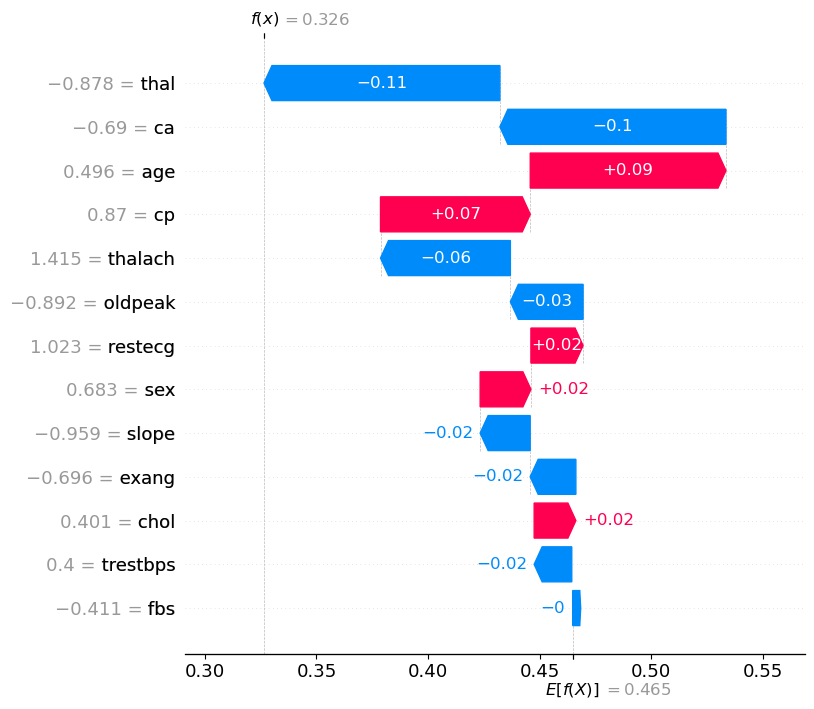

<Figure size 640x480 with 0 Axes>

In [14]:
shap.plots.waterfall(shap_values[0, :, 1], max_display=13)

plt.savefig(
    FIGURES_PATH / "shap_waterfall_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
## Interpretation

The SHAP analysis provides insights into how the Random Forest model makes predictions.

The global feature importance plot identifies the most influential clinical variables across all patients,
while the beeswarm plot illustrates how high and low feature values affect prediction outcomes.

The waterfall plot demonstrates how individual patient characteristics contribute to the final prediction.
Such local explanations are particularly valuable in healthcare, as they increase transparency and support clinical decision-making.

Overall, SHAP improves the interpretability of the Random Forest model without reducing predictive performance,
making it more suitable for healthcare applications where explainability is essential.